In [1]:
import pandas as pd

# 1. Cargar archivos
df_tic = pd.read_csv('Tecnologías de información y comunicación.CSV', sep=';', encoding='latin-1')
df_vivienda = pd.read_csv('Datos de la vivienda.CSV', sep=';', encoding='latin-1')
df_ipm = pd.read_csv('hogares_2023_dpto.CSV', sep=',', encoding='latin-1')

# 2. Normalizar nombres a MAYÚSCULAS
df_tic.columns = df_tic.columns.str.upper().str.strip()
df_vivienda.columns = df_vivienda.columns.str.upper().str.strip()
df_ipm.columns = df_ipm.columns.str.upper().str.strip()

# 3. Asegurar que DIRECTORIO sea string
for d in [df_tic, df_vivienda, df_ipm]:
    d['DIRECTORIO'] = d['DIRECTORIO'].astype(str).str.strip()

# --- AQUÍ ESTÁ EL CAMBIO CRÍTICO ---
# 4. Seleccionar columnas de Vivienda incluyendo DEPARTAMENTO y CLASE
# Usamos 'P1_DEPARTAMENTO' porque así viene en la ECV
cols_vivienda = ['DIRECTORIO', 'P1_DEPARTAMENTO', 'CLASE'] 

# Verificación de seguridad: si por alguna razón no se llama P1_DEPARTAMENTO, 
# este código busca la que más se parezca
if 'P1_DEPARTAMENTO' not in df_vivienda.columns:
    col_depto_viv = [c for c in df_vivienda.columns if 'DEP' in c][0]
    cols_vivienda[1] = col_depto_viv

# 5. EL GRAN CRUCE
# Unimos TIC con las columnas seleccionadas de Vivienda
df_temp = pd.merge(df_tic, df_vivienda[cols_vivienda], on='DIRECTORIO', how='inner')

# Unimos con IPM para tener la etiqueta 'POBRE'
df_final = pd.merge(df_temp, df_ipm[['DIRECTORIO', 'POBRE']], on='DIRECTORIO', how='inner')

print(f"¡ÉXITO! Filas finales: {df_final.shape[0]}")
print(f"Columnas presentes: {'P1_DEPARTAMENTO' in df_final.columns}") # Debería decir True

¡ÉXITO! Filas finales: 225637
Columnas presentes: True


In [ ]:
# DICCIONARIO PARA PERSONALIZAR NOMBRES
# Instrucción: Cambia el texto después de los dos puntos ':' por el nombre que quieras.
diccionario_nombres = {
    # --- IDENTIFICADORES Y GEOGRAFÍA ---
    'P1_DEPARTAMENTO': 'Departamento',
    'CLASE': 'Zona Urbano Rural',

    # --- Conexión a Internet ---
    'P765S1': 'Computador de Escritorio',
    'P765S2': 'Computador Portatil',
    'P765S3': 'Tableta',
    'P765S4': 'Telefono Celular',
    'P765S5': 'Consolo para juegos',
    'P765S6': 'Televisor inteligente',
    'P765S7': 'Reproductor de musica',

    
    # --- Razon Que no Utiliza internet ---
    'P1929': 'Cual es la razon por la que no utiliza internet',

    # --- Habilidades Digitales ---
    'P1710S1': 'Hab Procesador Texto',
    'P1710S2': 'Hab Mover Archivos',
    'P1710S3': 'Hab Enviar Correos',
    'P1710S4': 'Hab Conectar Equipos',
    'P1710S5': 'Hab Excel Formulas',
    'P1710S6': 'Hab Presentaciones',
    'P1710S7': 'Hab Transferir Archivos',
    'P1710S8': 'Hab Instalar Software',
    'P1710S9': 'Hab Programacion',
    'P1710S10': 'Hab Seguridad Digital',
    'P1710S11': 'Hab Privacidad Datos',
    'P1710S12': 'Hab Verificar Noticias',

    # --- Usos de Internet ---
    'P1083S1': 'Uso Int Informacion',
    'P1083S2': 'Uso Int Correos Electronicos',
    'P1083S3': 'Uso Int Redes Sociales',
    'P1083S4': 'Uso Int Compras',
    'P1083S5': 'Uso Int Banca Electronica',
    'P1083S6': 'Uso Int Educacion',
    'P1083S7': 'Uso Int Tramites Gobierno',
    'P1083S8': 'Uso Int Descargas',
    'P1083S9': 'Uso Int Medios de Comunicacion',
    'P1083S10': 'Uso Int Audiovisual',
    'P1083S12': 'Uso Int Buscar Trabajo',
    'P1083S13': 'Uso Int Nube',
    'P1083S14': 'Uso Int Vender Productos',
    'P1083S15': 'Uso Int Trabajar',
    'P1083S16': 'Uso Int Llamadas',
    'P1083S17': 'Uso Int Publicar y Calificar Servicios',
    'P1083S18': 'Uso Int Post',

    # --- Uso Telefono Celular ---
    'P1080S1': 'Uso Tel Lamadas Personales',
    'P1080S2': 'Uso Tel Lamadas Laborales',
    'P1080S3': 'Uso Tel Mensajes de Texto',
    'P1080S4': 'Uso Tel Navegacion en Internet',
    
    # --- Uso Dispositivos ---
    'P1910': 'Frec Uso PC Escritorio',
    'P1911': 'Frec Uso Laptop',
    'P1912': 'Frec Uso Tableta',
    
    # --- Servicio de Telefonia ---
    'P803': 'Pago Servicio de Telefonia Celular',
    'P803S1': 'Valor Pagado Servicio Telefonia',
   

    # --- Uso de Señal de Radio ---
    'P805S1': 'Uso Radio Entretenimiento',
    'P805S2': 'Uso Radio Noticias',
    'P805S3': 'Uso Radio Entretenimiento',

    # --- Usa Telefono Celular aunque no sea propio ---
    'P5504': 'Usa Telefono Celular Sin Ser Propio',

    # --- Tiene Celular ---
    'P1082': 'Tiene Celular',
    'P1082S1': 'Tiene Celular Basico',
    'P1082S2': 'Tiene Smartphone',
     # --- Lugar Acceso Interner ---
    'P1085S1': 'Acceso Int en Hogar',
    'P1085S2': 'Acceso Int en trabajo',
    'P1085S3': 'Acceso Int en Institucion Educativa',
    'P1085S4': 'Acceso Int Publico Gratis',
    'P1085S5': 'Acceso Int Publico Costo',
    'P1085S6': 'Acceso Int Vivienta de Otra Persona',
    # --- Frecuencia Uso internet ---
    'P1084': 'Frecuencia Uso Int'
}

# --- PROCESO DE APLICACIÓN (No tocar esta parte) ---
df_final = df_final.rename(columns=diccionario_nombres)
identificadores_finales = ['DIRECTORIO', 'Departamento', 'POBRE']
X_columns = [c for c in df_final.columns if c not in identificadores_finales]

print(f"✅ ¡Base renombrada! Ahora tienes {len(diccionario_nombres)} variables personalizadas.")

✅ ¡Base renombrada! Ahora tienes 62 variables personalizadas.


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. ELIMINACIÓN DE BASURA
cols_a_borrar = [
    'SECUENCIA_ENCUESTA', 'SECUENCIA_P', 'ORDEN', 'FEX_C', 'PERIODO',
    'P805', 'P805S4', 'P805S5', 'P1080', 'P1080S5', 'P1080S6', 
    'P5505', 'P5505S1', 'P1085S8', 'P1083', 'P765S8', 'P769', 'P1710', 
    'P1083S11', 'P804', 'P5504S1', 'P5504S2', 'P5505S2', 'P1085','P765', 'P1085S7'   
]
df_final = df_final.drop(columns=cols_a_borrar, errors='ignore')

# 2. ESTANDARIZAR NOMBRE DEL DEPARTAMENTO
for col in df_final.columns:
    if 'DEPARTAMENTO' in col.upper():
        df_final = df_final.rename(columns={col: 'Departamento'})
        break

# 3. DEFINICIÓN DE ROLES
identificadores = ['DIRECTORIO', 'Departamento', 'POBRE']
# X_columns se define inicialmente aquí, pero se actualizará tras las transformaciones
X_columns = [c for c in df_final.columns if c not in identificadores]

# 4. LIMPIEZA Y TRANSFORMACIÓN DE VARIABLES ESPECIALES (ORDINALES Y BRECHAS)
# -------------------------------------------------------------------------

# A. ELIMINAR COLUMNAS DUPLICADAS
df_final = df_final.loc[:, ~df_final.columns.duplicated()].copy()

# B. MAPEO DE INTENSIDAD (1-5 -> 4-0)
mapeo_intensidad = {1: 4, 2: 3, 3: 2, 4: 1, 5: 0}

columnas_frecuencia = [
    'Frec Uso PC Escritorio', 
    'Frec Uso Laptop', 
    'Frec Uso Tableta', 
    'Frecuencia_Uso_Internet'
]

for col in columnas_frecuencia:
    if col in df_final.columns:
        col_data = df_final[col]
        if isinstance(col_data, pd.DataFrame): 
            col_data = col_data.iloc[:, 0]
            
        # CAMBIO AQUÍ: Usamos espacio en lugar de guion bajo
        nuevo_nombre = f'Intensidad {col}'
        df_final[nuevo_nombre] = col_data.map(mapeo_intensidad).fillna(0)

# C. PILARES DE LA BRECHA DIGITAL
col_razon = 'Cual es la razon por la que no utiliza internet'

if col_razon in df_final.columns:
    razon_data = df_final[col_razon]
    if isinstance(razon_data, pd.DataFrame):
        razon_data = razon_data.iloc[:, 0]
        
    df_final['Brecha de Internet por Costo'] = (razon_data == 1).astype(int)
    df_final['Brecha de Internet por Cobertura'] = (razon_data == 4).astype(int)
    df_final['Brecha de Internet por Habilidad'] = (razon_data == 3).astype(int)

# D. ELIMINACIÓN DE ORIGINALES Y ACTUALIZACIÓN DE PREDICTORES
cols_para_borrar = [col_razon] + columnas_frecuencia
df_final = df_final.drop(columns=cols_para_borrar, errors='ignore')

# RE-DEFINIMOS X_columns con los nuevos nombres (ahora con espacios)
X_columns = [c for c in df_final.columns if c not in identificadores]

# E. BUCLE DE LIMPIEZA MASIVA
for col in X_columns:
    serie = df_final[col]
    if isinstance(serie, pd.DataFrame):
        serie = serie.iloc[:, 0]
    
    df_final[col] = pd.to_numeric(serie, errors='coerce')
    
    vals = set(df_final[col].dropna().unique())
    if vals == {1, 2}:
        df_final[col] = df_final[col].replace(2, 0)
    
    df_final[col] = df_final[col].fillna(0)

print("✅ Limpieza completada sin errores de duplicidad.")

# 5. DETERMINACIÓN DE VARIABLES PARA EL MODELO
X = df_final[X_columns]
y = df_final['POBRE'].astype(int)

# 6. DIVISIÓN DE DATOS (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. VERIFICACIÓN FINAL
print(f"{'='*40}")
print(f"🚀 BASE LISTA PARA EL RANDOM FOREST")
print(f"{'='*40}")
print(f"🎯 Variable Objetivo:      POBRE")
print(f"📊 Total Predictores (X):  {X.shape[1]}")
print(f"🏠 Total de Registros:     {len(df_final)}")
print(f"📝 Variables de Intensidad: {[c for c in X.columns if 'Intensidad' in c]}")
print(f"📉 Variables de Brecha:     {[c for c in X.columns if 'Brecha' in c]}")
print(f"{'='*40}")

✅ Limpieza completada sin errores de duplicidad.
🚀 BASE LISTA PARA EL RANDOM FOREST
🎯 Variable Objetivo:      POBRE
📊 Total Predictores (X):  63
🏠 Total de Registros:     225637
📝 Variables de Intensidad: ['Intensidad Frec Uso PC Escritorio', 'Intensidad Frec Uso Laptop', 'Intensidad Frec Uso Tableta']
📉 Variables de Brecha:     ['Brecha de Internet por Costo', 'Brecha de Internet por Cobertura', 'Brecha de Internet por Habilidad']


--- ESTADÍSTICAS DESCRIPTIVAS (BLOQUE 1) ---


,count,mean,std,min,25%,50%,75%,max
Valor Pagado Servicio Telefonia,225637.0,13025.936150,21784.944842,0.0,0.0,3000.0,20000.0,900000.0
Frecuencia Uso Int,225637.0,2.577645,1.774501,1.0,1.0,2.0,5.0,5.0
Tiene Smartphone,225637.0,0.602011,0.489484,0.0,0.0,1.0,1.0,1.0
POBRE,225637.0,0.195491,0.396579,0.0,0.0,0.0,0.0,1.0


C:\Users\jpabl\AppData\Local\Temp\ipykernel_11704\1093124607.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='POBRE', data=df_visual, palette=['#34495E', '#E74C3C'])


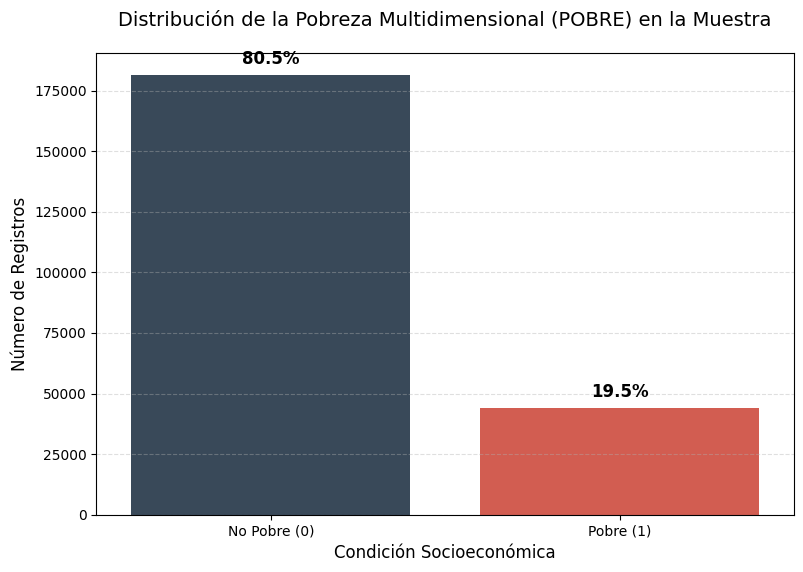

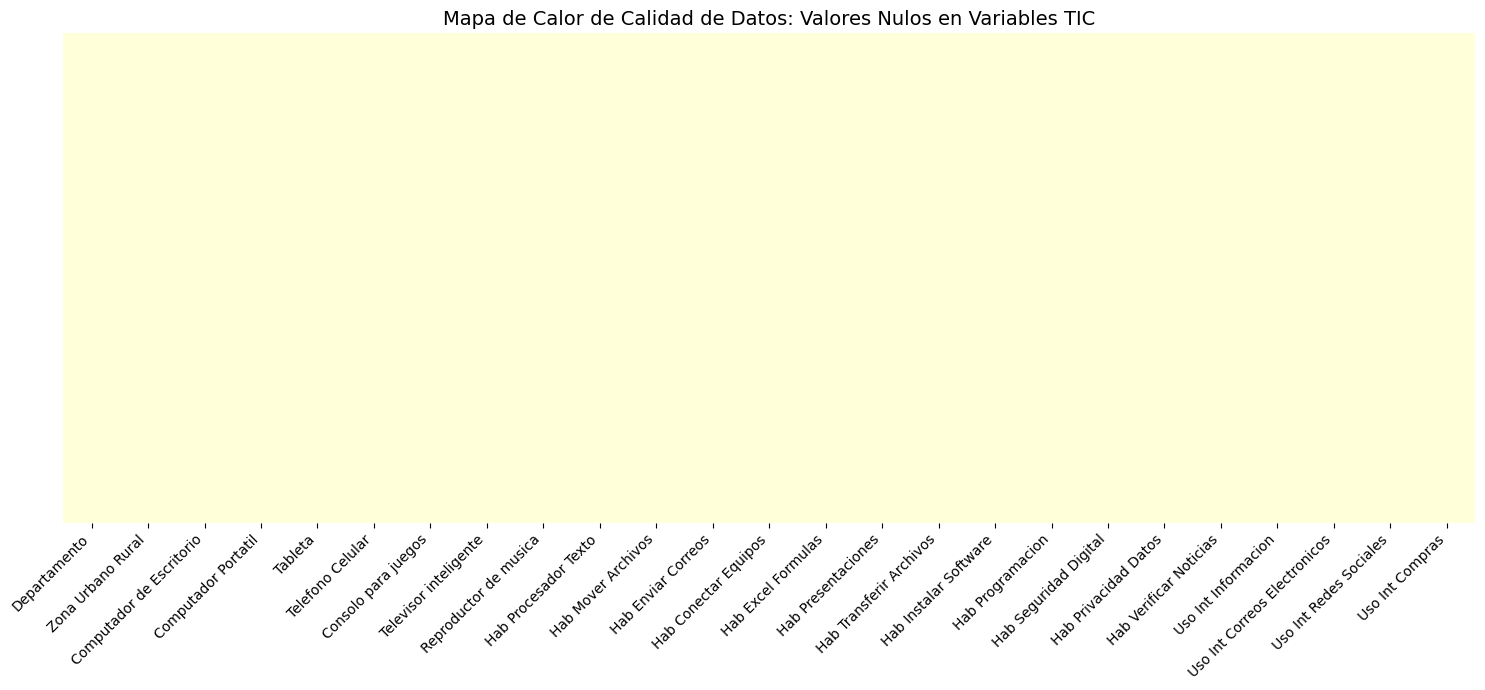

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Aplicar el diccionario al dataframe correcto
df_visual = df_final.rename(columns=diccionario_nombres)

# 2. Definir variables para la tabla descriptiva (asegurando que existan)
# 'POBRE' es nuestra variable objetivo ahora
vars_interes = [
    'Valor Pagado Servicio Telefonia', 
    'Frecuencia Uso Int', 
    'Tiene Smartphone',
    'POBRE' 
]
vars_existentes = [v for v in vars_interes if v in df_visual.columns]

# 3. Mostrar la tabla descriptiva
print("--- ESTADÍSTICAS DESCRIPTIVAS (BLOQUE 1) ---")
display(df_visual[vars_existentes].describe().T)

# 4. Gráfico de Distribución de Pobreza (POBRE)
plt.figure(figsize=(9, 6))
# Colores institucionales: Azul Grisáceo y Rojo Coral
ax = sns.countplot(x='POBRE', data=df_visual, palette=['#34495E', '#E74C3C'])

plt.title('Distribución de la Pobreza Multidimensional (POBRE) en la Muestra', fontsize=14, pad=20)
plt.xticks([0, 1], ['No Pobre (0)', 'Pobre (1)'])
plt.xlabel('Condición Socioeconómica', fontsize=12)
plt.ylabel('Número de Registros', fontsize=12)

# Añadir etiquetas de porcentaje
total = len(df_visual)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height),
                ha='center', va='baseline', fontsize=12, fontweight='bold', color='black', xytext=(0, 8),
                textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# 5. Mapa de Calor de Datos Faltantes (Heatmap)
# Seleccionamos las columnas que vienen del diccionario y que estén en el DF
cols_tic = [col for col in diccionario_nombres.values() if col in df_visual.columns]

plt.figure(figsize=(15, 7))
sns.heatmap(df_visual[cols_tic[:25]].isnull(), yticklabels=False, cbar=False, cmap='YlGnBu')
plt.title('Mapa de Calor de Calidad de Datos: Valores Nulos en Variables TIC', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\jpabl\AppData\Local\Temp\ipykernel_11704\4174275674.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pobreza_ranking.values, y=pobreza_ranking.index, palette='Reds_r')


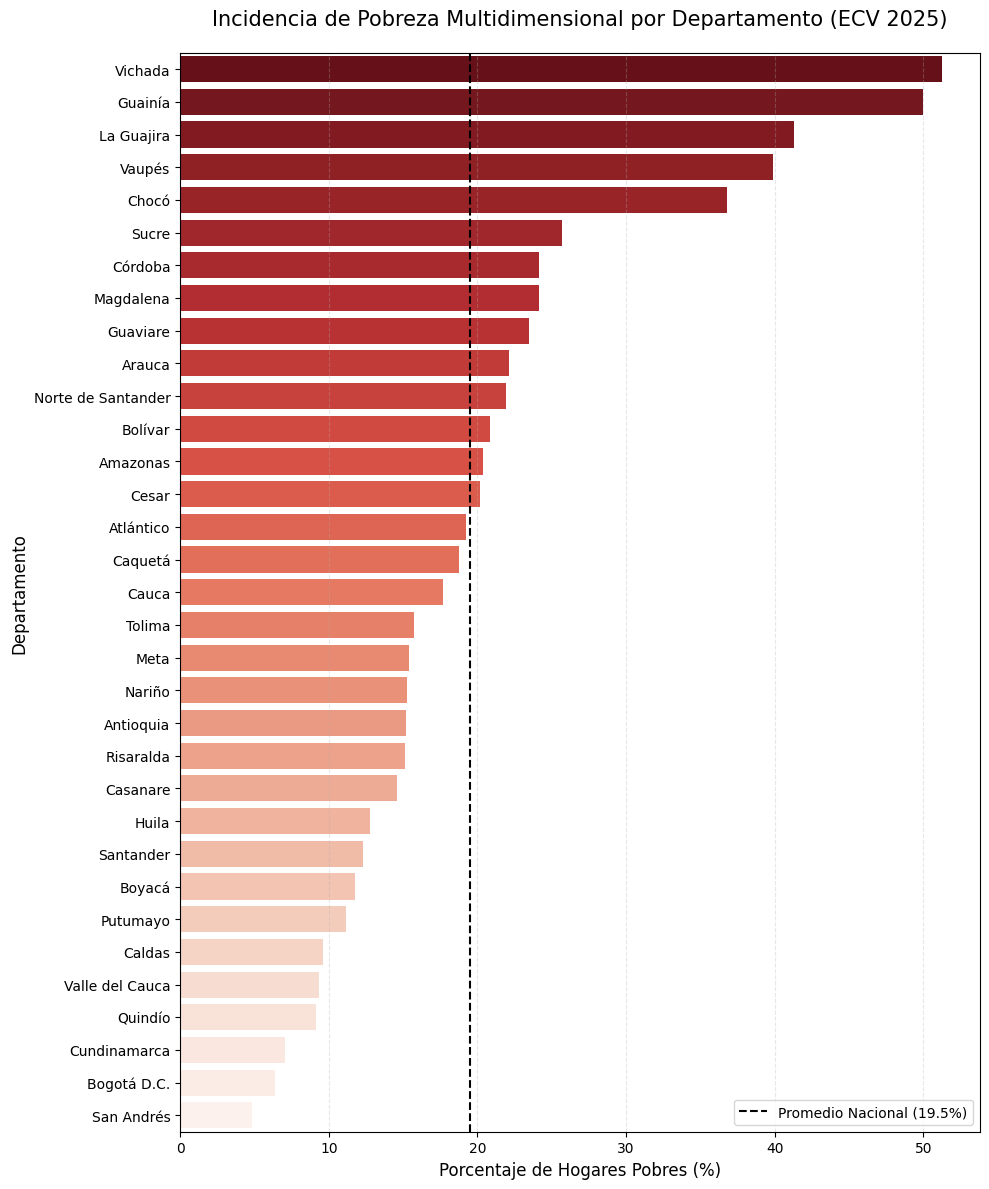

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DICCIONARIO OFICIAL DE DEPARTAMENTOS (DIVIPOLA)
diccionario_deptos = {
    5: 'Antioquia', 8: 'Atlántico', 11: 'Bogotá D.C.', 13: 'Bolívar', 15: 'Boyacá',
    17: 'Caldas', 18: 'Caquetá', 19: 'Cauca', 20: 'Cesar', 23: 'Córdoba',
    25: 'Cundinamarca', 27: 'Chocó', 41: 'Huila', 44: 'La Guajira', 47: 'Magdalena',
    50: 'Meta', 52: 'Nariño', 54: 'Norte de Santander', 63: 'Quindío', 66: 'Risaralda',
    68: 'Santander', 70: 'Sucre', 73: 'Tolima', 76: 'Valle del Cauca', 81: 'Arauca',
    85: 'Casanare', 86: 'Putumayo', 88: 'San Andrés', 91: 'Amazonas', 94: 'Guainía',
    95: 'Guaviare', 97: 'Vaupés', 99: 'Vichada'
}

# 2. APLICAR EL MAPEO
# Convertimos a entero por si acaso vienen como texto
df_visual['Departamento'] = df_visual['Departamento'].astype(int).map(diccionario_deptos)

# 3. GENERAR EL GRÁFICO
plt.figure(figsize=(10, 12))

# Calculamos el % de pobreza por departamento
pobreza_ranking = df_visual.groupby('Departamento')['POBRE'].mean().sort_values(ascending=False) * 100

# Gráfico de barras horizontales
sns.barplot(x=pobreza_ranking.values, y=pobreza_ranking.index, palette='Reds_r')

# Línea del promedio nacional (19.5% según tu Bloque 1)
plt.axvline(x=19.5, color='black', linestyle='--', label='Promedio Nacional (19.5%)')

# Estética del gráfico
plt.title('Incidencia de Pobreza Multidimensional por Departamento (ECV 2025)', fontsize=15, pad=20)
plt.xlabel('Porcentaje de Hogares Pobres (%)', fontsize=12)
plt.ylabel('Departamento', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

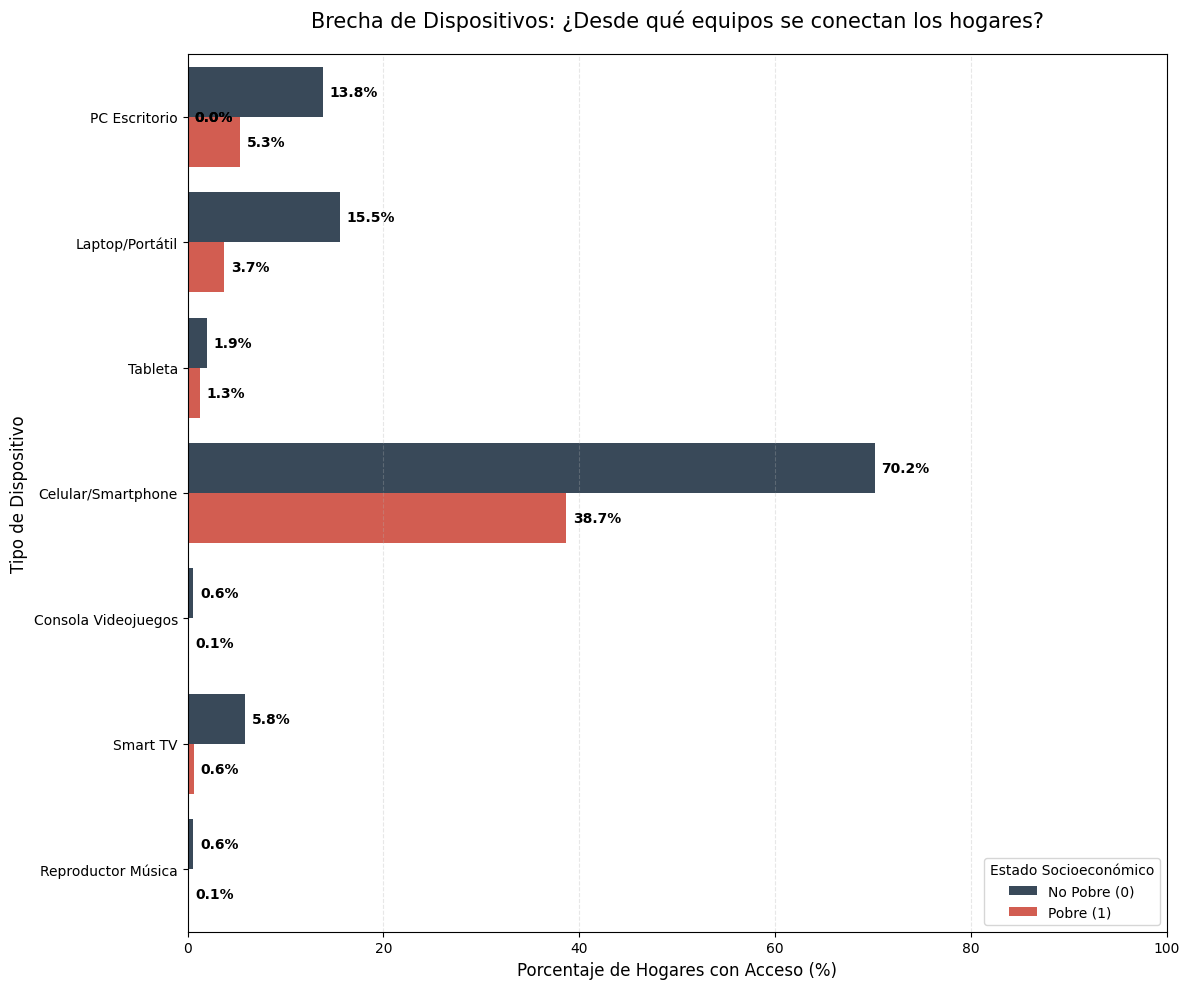

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mapeo de las variables P765 según tu diccionario
dispositivos_map = {
    'Computador de Escritorio': 'PC Escritorio',
    'Computador Portatil': 'Laptop/Portátil',
    'Tableta': 'Tableta',
    'Telefono Celular': 'Celular/Smartphone',
    'Consolo para juegos': 'Consola Videojuegos',
    'Televisor inteligente': 'Smart TV',
    'Reproductor de musica': 'Reproductor Música'
}

# 2. Preparar los datos
resumen_dispositivos = []

for col_larga, nombre_corto in dispositivos_map.items():
    if col_larga in df_visual.columns:
        # Calculamos el % de 'Sí' (valor 1) para cada nivel de POBRE
        # Aseguramos que la columna sea numérica
        df_visual[col_larga] = pd.to_numeric(df_visual[col_larga], errors='coerce').fillna(0)
        
        pct = df_visual.groupby('POBRE')[col_larga].mean() * 100
        
        resumen_dispositivos.append({'Dispositivo': nombre_corto, 'Condición': 'No Pobre (0)', 'Porcentaje': pct[0]})
        resumen_dispositivos.append({'Dispositivo': nombre_corto, 'Condición': 'Pobre (1)', 'Porcentaje': pct[1]})

df_plot = pd.DataFrame(resumen_dispositivos)

# 3. Graficar
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='Porcentaje', y='Dispositivo', hue='Condición', data=df_plot, palette=['#34495E', '#E74C3C'])

plt.title('Brecha de Dispositivos: ¿Desde qué equipos se conectan los hogares?', fontsize=15, pad=20)
plt.xlabel('Porcentaje de Hogares con Acceso (%)', fontsize=12)
plt.ylabel('Tipo de Dispositivo', fontsize=12)
plt.xlim(0, 100)

# Añadir etiquetas de valor al final de cada barra
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}%', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0),
                textcoords='offset points')

plt.legend(title='Estado Socioeconómico', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

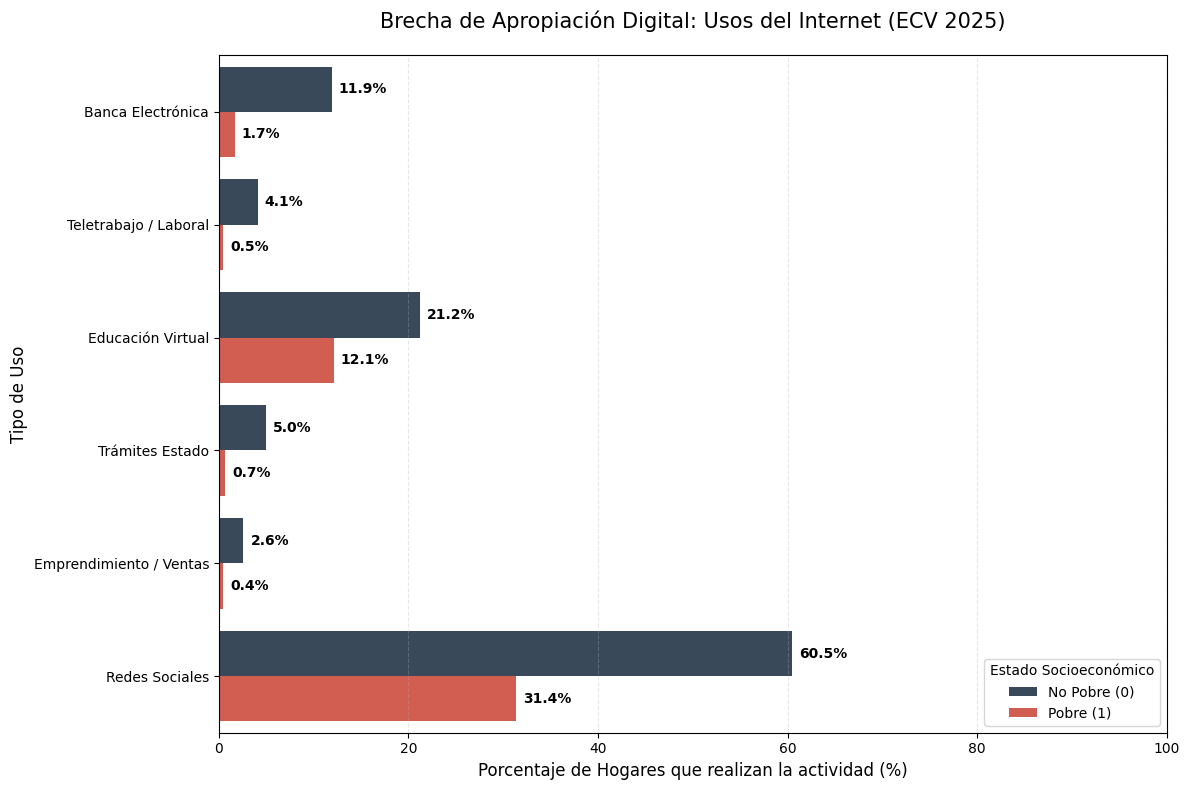

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lista de variables según tu diccionario exacto
# Seleccionamos las más relevantes para mostrar la brecha productiva
usos_interes = {
    'Uso Int Banca Electronica': 'Banca Electrónica',
    'Uso Int Trabajar': 'Teletrabajo / Laboral',
    'Uso Int Educacion': 'Educación Virtual',
    'Uso Int Tramites Gobierno': 'Trámites Estado',
    'Uso Int Vender Productos': 'Emprendimiento / Ventas',
    'Uso Int Redes Sociales': 'Redes Sociales'
}

# 2. Procesar los datos
resumen_usos = []

for col_diccionario, nombre_grafico in usos_interes.items():
    if col_diccionario in df_visual.columns:
        # Convertimos a numérico y normalizamos (1 es Sí, el resto es No)
        # En el DANE usualmente 1=Sí, 2=No.
        temp_data = pd.to_numeric(df_visual[col_diccionario], errors='coerce').fillna(0)
        serie_bool = (temp_data == 1).astype(int)
        
        # Calculamos porcentaje agrupado por POBRE
        pct = serie_bool.groupby(df_visual['POBRE']).mean() * 100
        
        # Guardamos resultados
        if 0 in pct.index:
            resumen_usos.append({'Actividad': nombre_grafico, 'Condición': 'No Pobre (0)', 'Porcentaje': pct[0]})
        if 1 in pct.index:
            resumen_usos.append({'Actividad': nombre_grafico, 'Condición': 'Pobre (1)', 'Porcentaje': pct[1]})

# 3. Crear DataFrame y Graficar
df_usos_final = pd.DataFrame(resumen_usos)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Porcentaje', y='Actividad', hue='Condición', data=df_usos_final, palette=['#34495E', '#E74C3C'])

plt.title('Brecha de Apropiación Digital: Usos del Internet (ECV 2025)', fontsize=15, pad=20)
plt.xlabel('Porcentaje de Hogares que realizan la actividad (%)', fontsize=12)
plt.ylabel('Tipo de Uso', fontsize=12)
plt.xlim(0, 100)

# Añadir etiquetas de porcentaje
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0),
                    textcoords='offset points')

plt.legend(title='Estado Socioeconómico', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

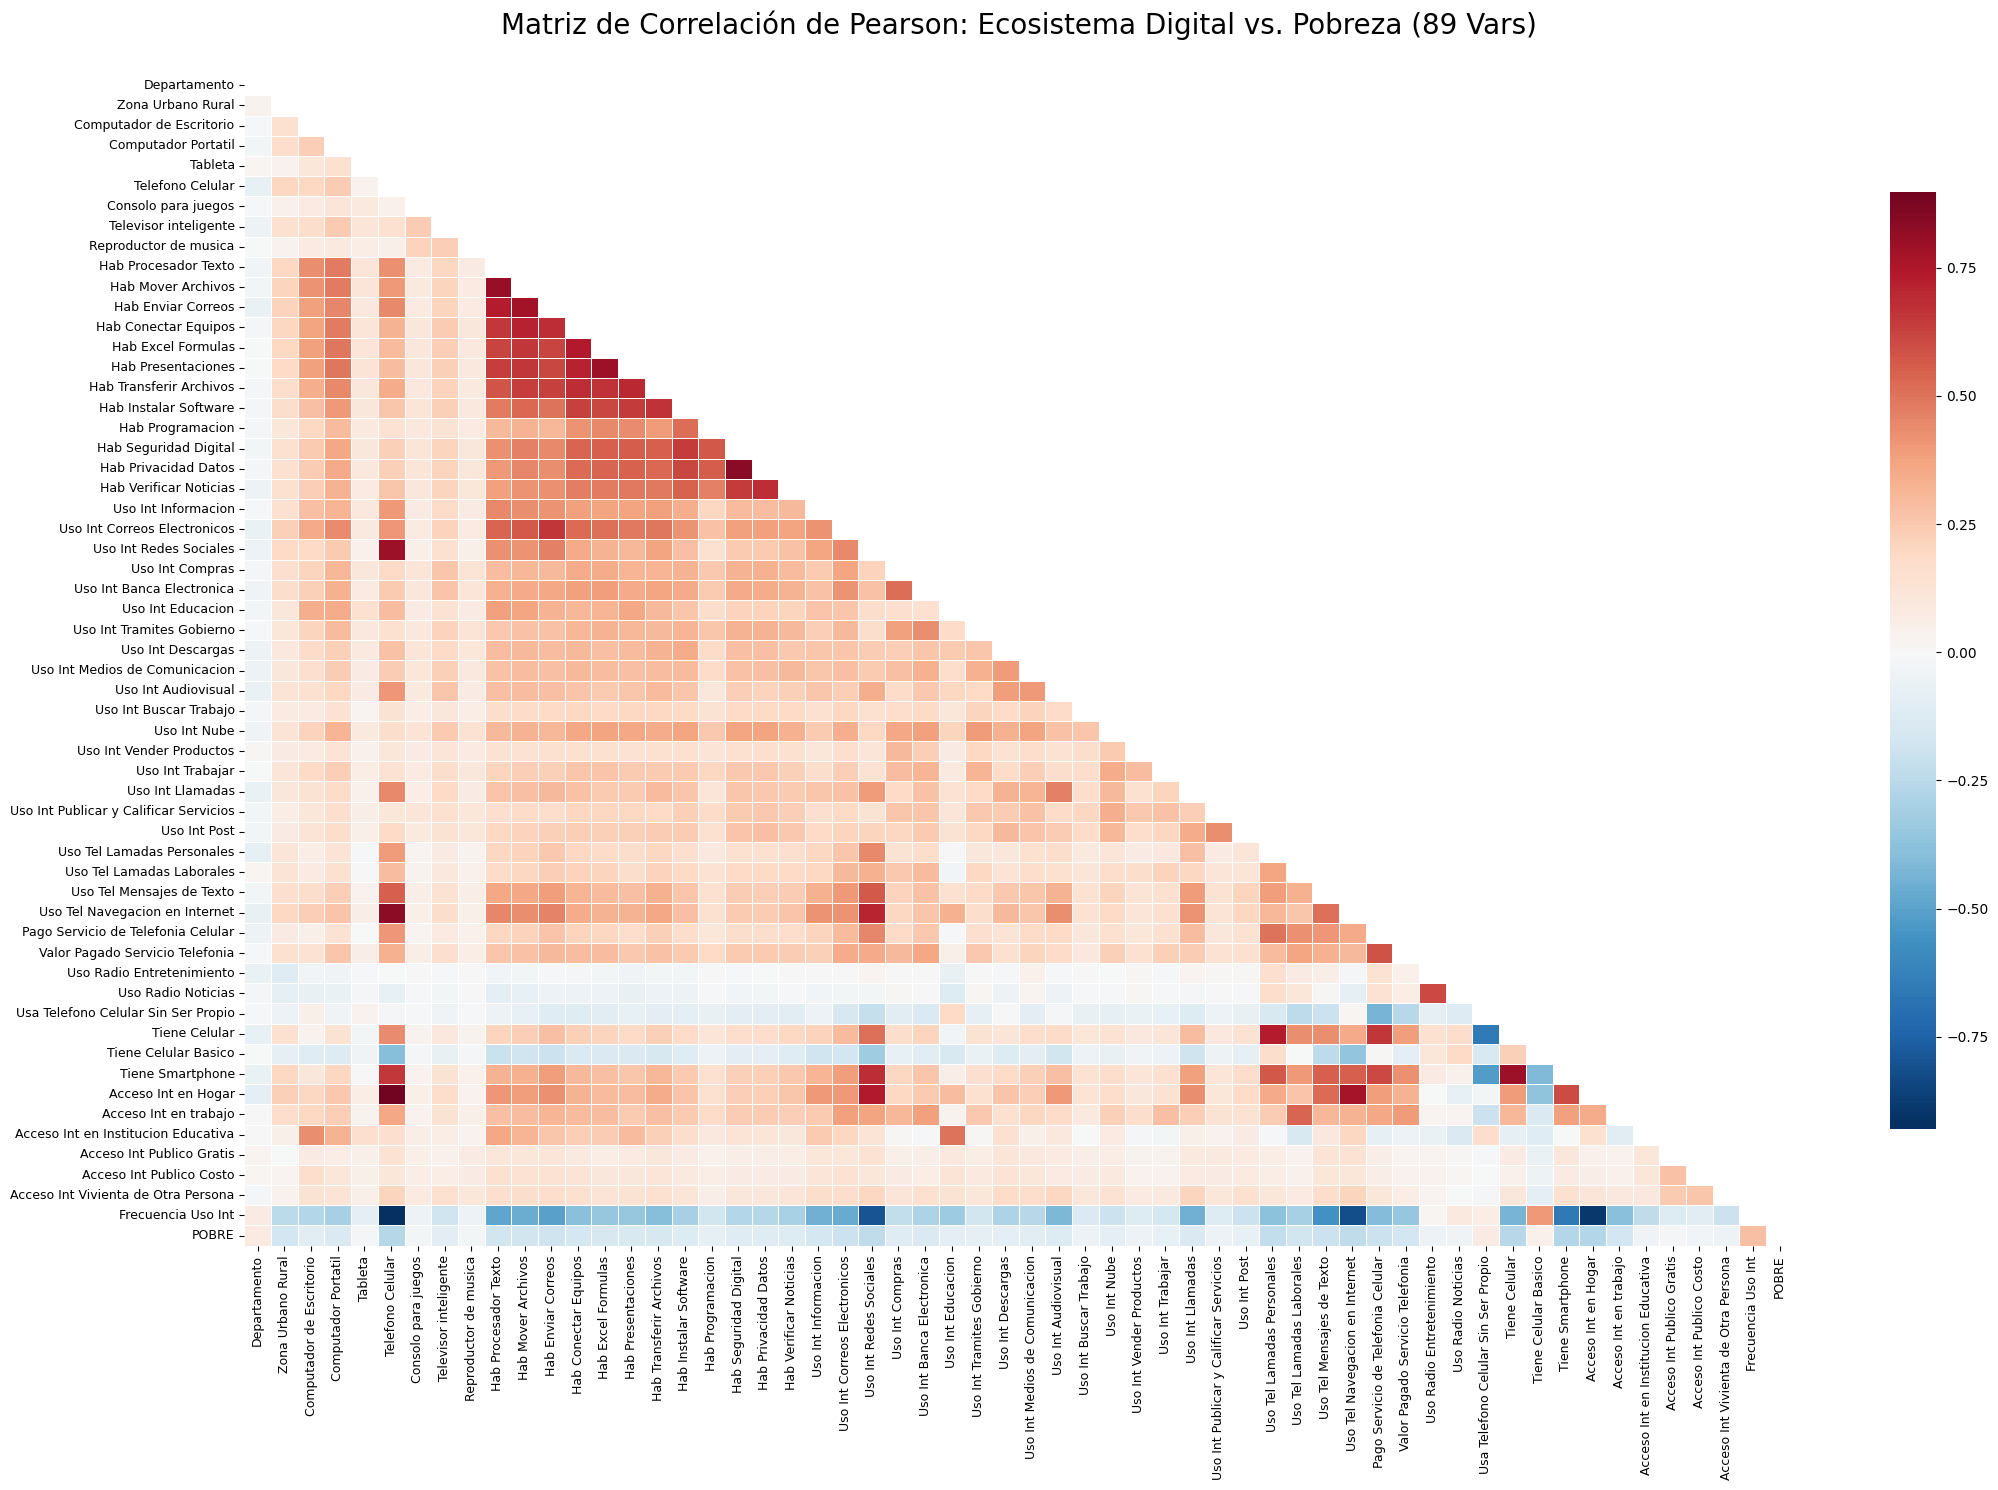

--- TOP 10 VARIABLES MÁS CORRELACIONADAS CON LA POBREZA ---
Frecuencia Uso Int                    0.282140
Acceso Int en Hogar                   0.267480
Tiene Smartphone                      0.266681
Telefono Celular                      0.260149
Tiene Celular                         0.255918
Uso Tel Navegacion en Internet        0.233301
Uso Int Redes Sociales                0.232181
Uso Tel Lamadas Personales            0.228195
Pago Servicio de Telefonia Celular    0.199774
Uso Tel Mensajes de Texto             0.197026
Name: POBRE, dtype: float64


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aseguramos que df_listo tenga las variables del diccionario y POBRE
# (Este df_listo viene del proceso de limpieza anterior)

# 2. Seleccionar variables para la correlación (filtramos las dummies de depto para que no saturen)
cols_corr = [c for c in df_listo.columns if 'Departamento_' not in c]

# 3. Calcular la matriz de correlación
# Usamos solo las variables que tengan variación (que no sean todo ceros)
matriz_corr = df_listo[cols_corr].corr()

# 4. Graficar un Heatmap de alta resolución
plt.figure(figsize=(22, 15))

# Creamos una máscara para ver solo la mitad inferior (es más profesional)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(matriz_corr, 
            mask=mask,
            cmap='RdBu_r', # Rojo es correlación negativa, Azul positiva
            center=0,
            annot=False, # Ponemos False porque son demasiadas variables para ver números
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación de Pearson: Ecosistema Digital vs. Pobreza (89 Vars)', fontsize=20, pad=30)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# 5. EL TOP 10: ¿Qué variables están más asociadas a la pobreza?
print("--- TOP 10 VARIABLES MÁS CORRELACIONADAS CON LA POBREZA ---")
top_corr = matriz_corr['POBRE'].abs().sort_values(ascending=False).head(11)
print(top_corr[1:]) # Quitamos POBRE vs POBRE

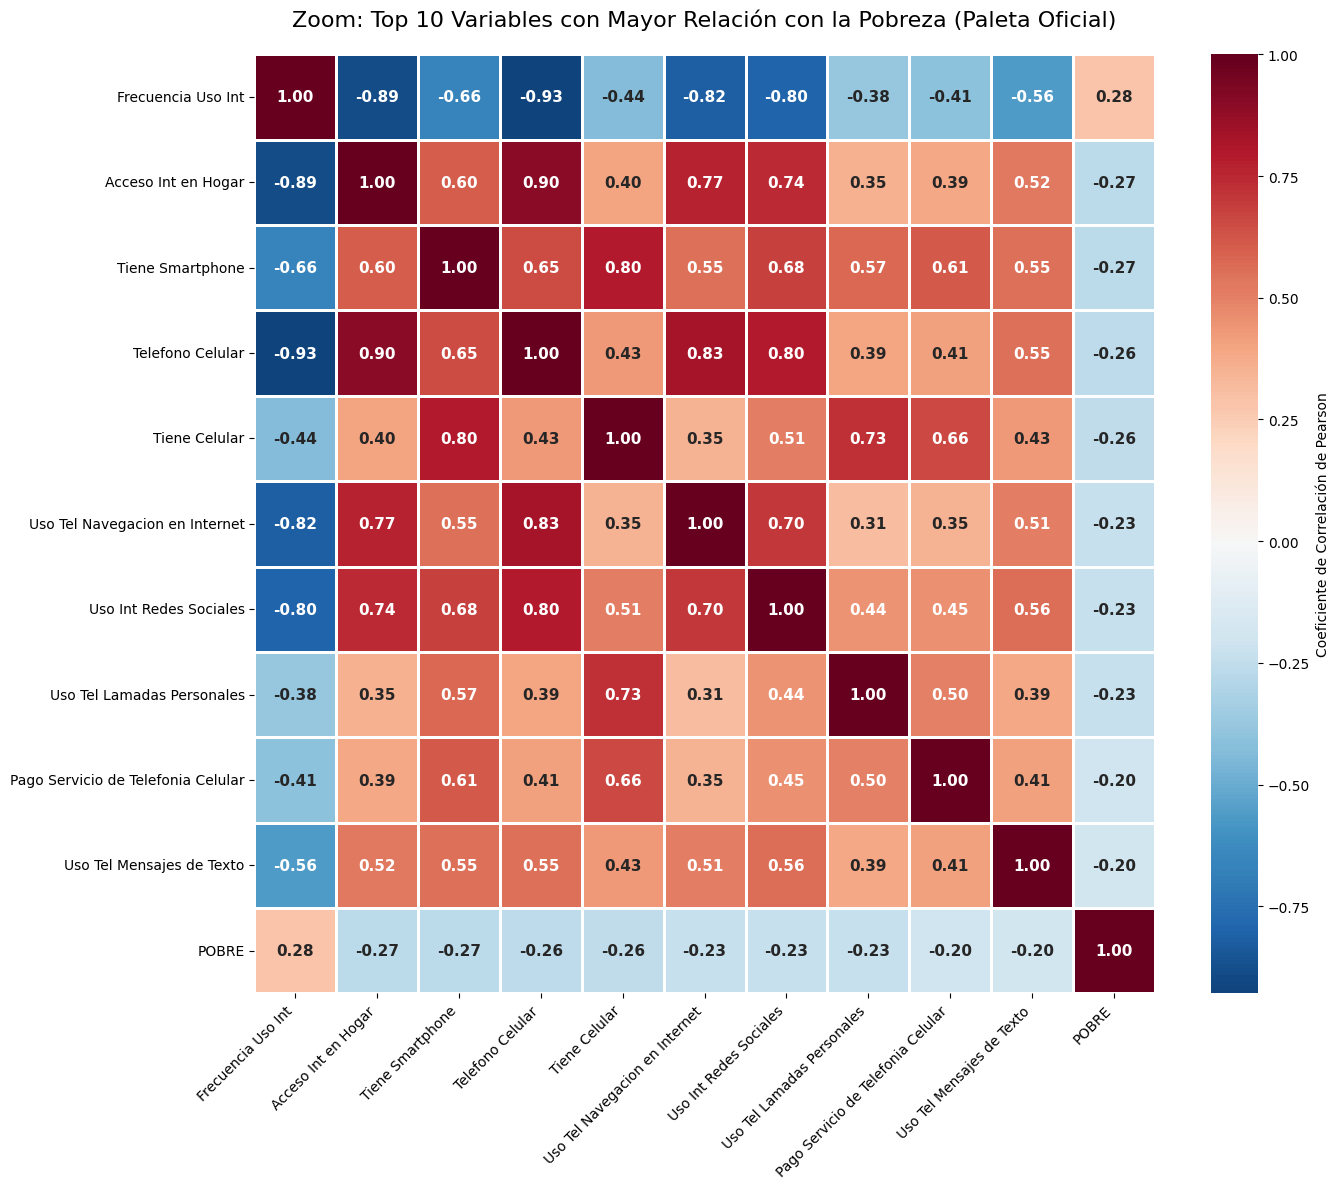

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos el Top 10 basado en tu resultado exacto
top_10_nombres = [
    'Frecuencia Uso Int', 'Acceso Int en Hogar', 'Tiene Smartphone', 
    'Telefono Celular', 'Tiene Celular', 'Uso Tel Navegacion en Internet', 
    'Uso Int Redes Sociales', 'Uso Tel Lamadas Personales', 
    'Pago Servicio de Telefonia Celular', 'Uso Tel Mensajes de Texto'
]

# 2. Creamos la matriz solo con esas variables + POBRE
matriz_top = df_listo[top_10_nombres + ['POBRE']].corr()

# 3. Graficamos con la paleta de colores coherente (RdBu_r)
plt.figure(figsize=(14, 12)) # Un poco más grande para que queden cómodos los números

sns.heatmap(matriz_top, 
            annot=True,          # Mostramos los números (son poquitas variables)
            fmt=".2f",           # Dos decimales
            cmap='RdBu_r',       # LA PALETA CORRECTA (Rojo: Negativo, Azul: Positivo)
            center=0,            # El blanco es la ausencia de correlación
            linewidths=1,        # Líneas divisorias
            cbar_kws={"label": "Coeficiente de Correlación de Pearson"},
            annot_kws={"size": 11, "weight": "bold"}) # Números claros y en negrita

plt.title('Zoom: Top 10 Variables con Mayor Relación con la Pobreza (Paleta Oficial)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

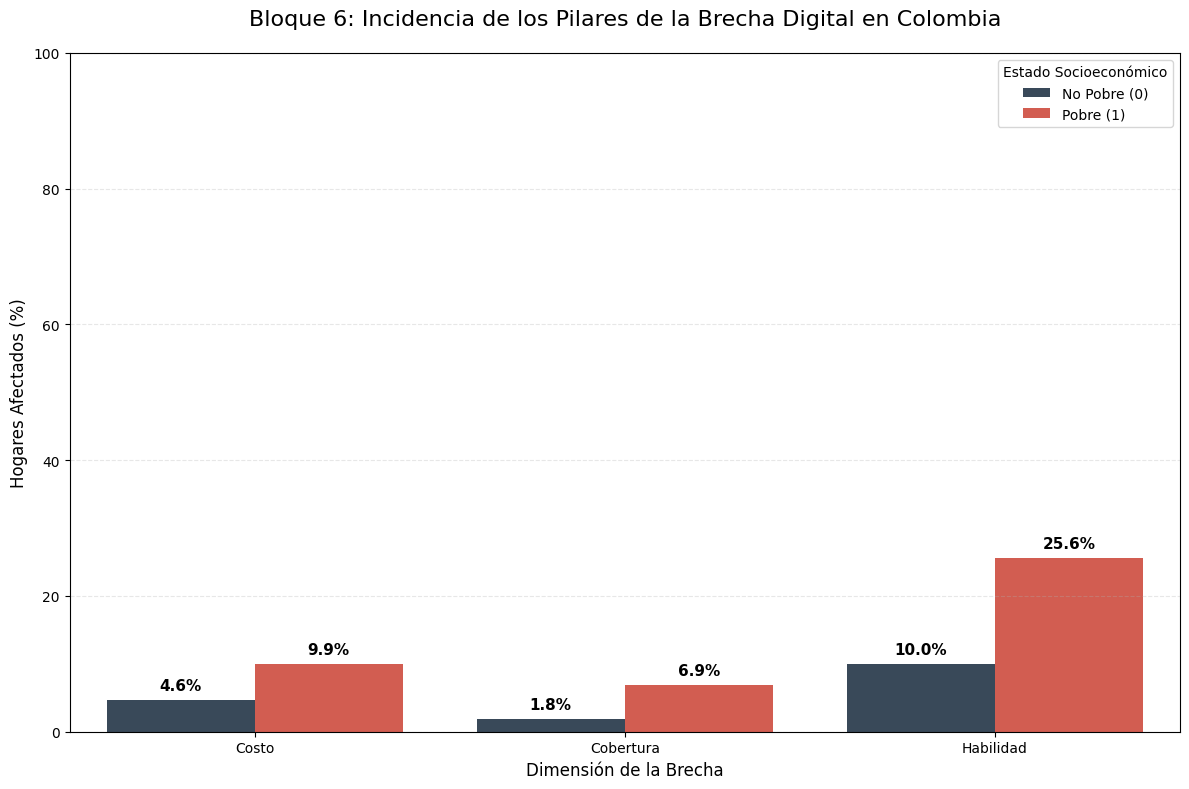

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lista exacta de tus variables (basada en tu imagen)
pilares = [
    'Brecha de Internet por Costo', 
    'Brecha de Internet por Cobertura', 
    'Brecha de Internet por Habilidad'
]

# 2. Procesar los datos usando df_final que es donde confirmamos que están
resumen_pilares = []

for pilar in pilares:
    if pilar in df_final.columns:
        # Calculamos el porcentaje de incidencia por condición de POBRE
        # Como son int64 y tienen 0 y 1, el mean() * 100 nos da el porcentaje de "1s"
        pct = df_final.groupby('POBRE')[pilar].mean() * 100
        
        # Añadimos los resultados a la lista
        if 0 in pct.index:
            resumen_pilares.append({
                'Pilar': pilar.replace('Brecha de Internet por ', ''), 
                'Condición': 'No Pobre (0)', 
                'Porcentaje': pct[0]
            })
        if 1 in pct.index:
            resumen_pilares.append({
                'Pilar': pilar.replace('Brecha de Internet por ', ''), 
                'Condición': 'Pobre (1)', 
                'Porcentaje': pct[1]
            })

# 3. Crear DataFrame para el gráfico
df_pilares_plot = pd.DataFrame(resumen_pilares)

# 4. Graficar con los colores oficiales
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Pilar', y='Porcentaje', hue='Condición', data=df_pilares_plot, palette=['#34495E', '#E74C3C'])

plt.title('Bloque 6: Incidencia de los Pilares de la Brecha Digital en Colombia', fontsize=16, pad=20)
plt.ylabel('Hogares Afectados (%)', fontsize=12)
plt.xlabel('Dimensión de la Brecha', fontsize=12)
plt.ylim(0, 100)

# Añadir etiquetas de porcentaje sobre las barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

plt.legend(title='Estado Socioeconómico', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\jpabl\AppData\Local\Temp\ipykernel_11704\625391236.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='POBRE', y='Valor Pagado Servicio Telefonia', data=df_gasto_plot,
C:\Users\jpabl\AppData\Local\Temp\ipykernel_11704\625391236.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='POBRE', y='Frecuencia Uso Int', data=df_final,
C:\Users\jpabl\AppData\Local\Temp\ipykernel_11704\625391236.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='POBRE', y='Diversidad Dispositivos', data=df_final,
C:\Users\jpabl\AppData\Local\Temp\i

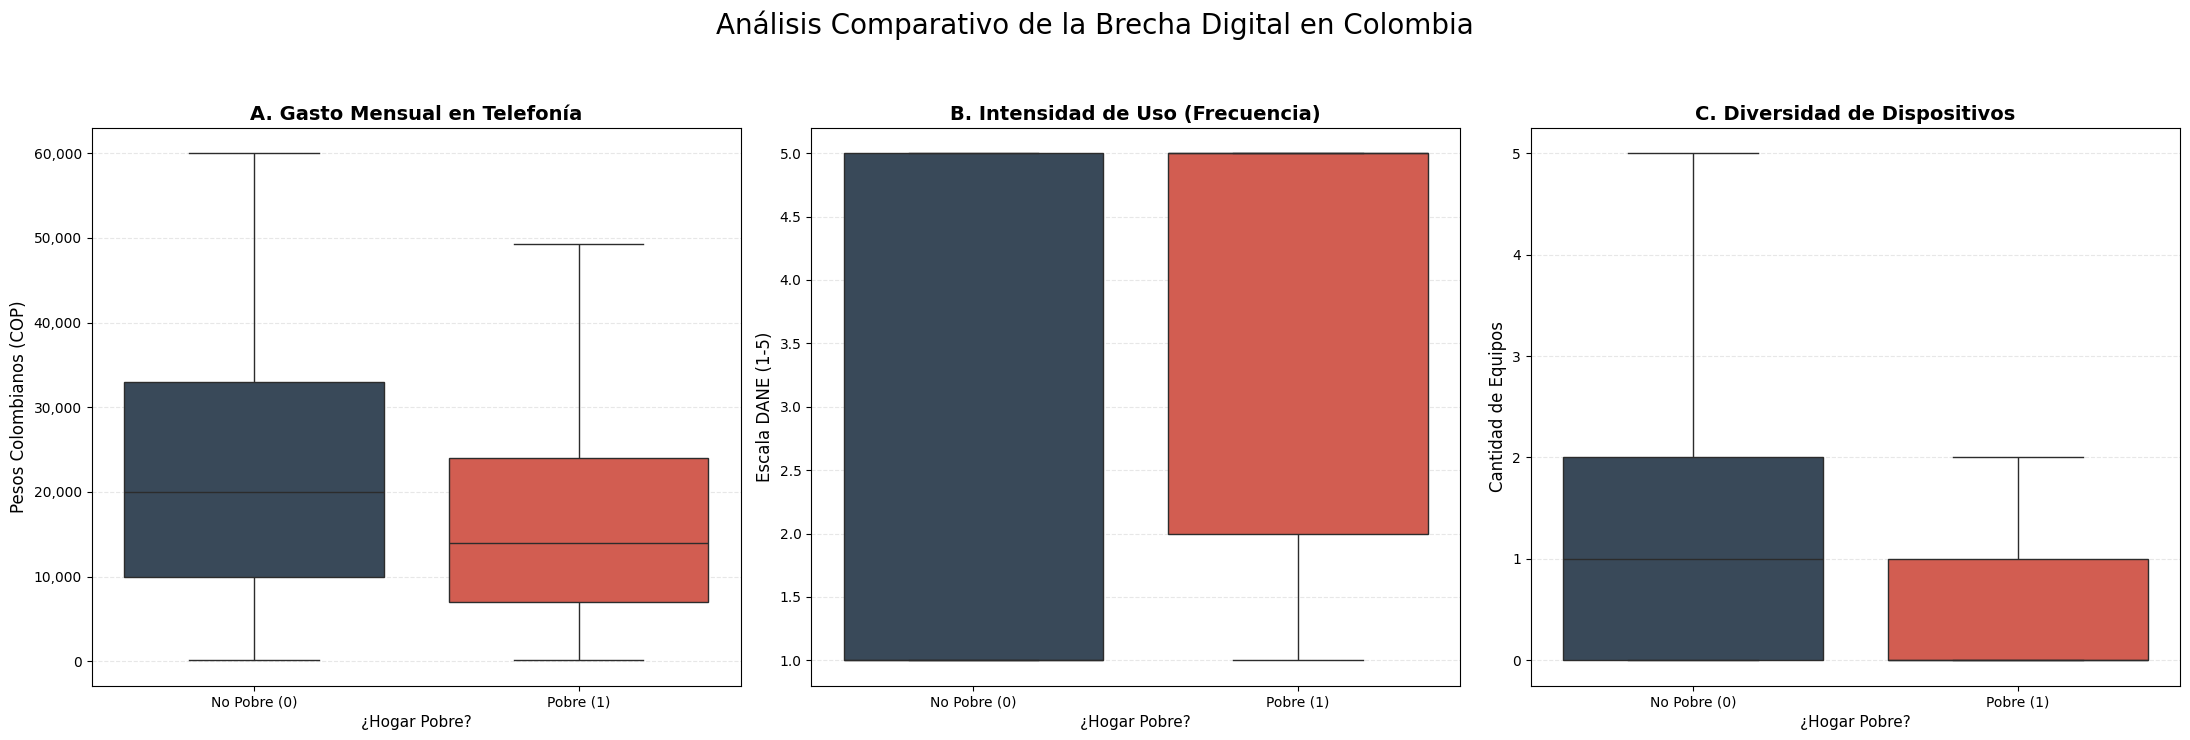

--- MEDIANAS POR GRUPO ---
       Valor Pagado Servicio Telefonia  Frecuencia Uso Int  \
POBRE                                                        
0                               6500.0                 1.0   
1                                  0.0                 5.0   

       Diversidad Dispositivos  
POBRE                           
0                          1.0  
1                          0.0  


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARACIÓN DE VARIABLES
# A. Diversidad de Dispositivos (Suma de equipos)
columnas_equipos = ['Computador de Escritorio', 'Computador Portatil', 'Tableta', 'Telefono Celular', 'Televisor inteligente']
cols_presentes = [c for c in columnas_equipos if c in df_final.columns]
df_final['Diversidad Dispositivos'] = df_final[cols_presentes].sum(axis=1)

# B. Limpieza de Gasto (Solo mayores a 0 y sin outliers extremos para el gráfico)
df_gasto_clean = df_final[df_final['Valor Pagado Servicio Telefonia'] > 0].copy()
p95_gasto = df_gasto_clean['Valor Pagado Servicio Telefonia'].quantile(0.95)
df_gasto_plot = df_gasto_clean[df_gasto_clean['Valor Pagado Servicio Telefonia'] <= p95_gasto]

# 2. CONFIGURACIÓN DE LA FIGURA (3 Subplots)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
paleta = ['#34495E', '#E74C3C'] # Azul Grisáceo (No Pobre) y Rojo (Pobre)

# --- GRÁFICO 1: GASTO MENSUAL ---
sns.boxplot(x='POBRE', y='Valor Pagado Servicio Telefonia', data=df_gasto_plot, 
            palette=paleta, ax=ax1, showfliers=False)
ax1.set_title('A. Gasto Mensual en Telefonía', fontsize=14, fontweight='bold')
ax1.set_ylabel('Pesos Colombianos (COP)', fontsize=12)
# Formato de miles para el eje Y
import matplotlib.ticker as ticker
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# --- GRÁFICO 2: INTENSIDAD DE USO ---
sns.boxplot(x='POBRE', y='Frecuencia Uso Int', data=df_final, 
            palette=paleta, ax=ax2, showfliers=False)
ax2.set_title('B. Intensidad de Uso (Frecuencia)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Escala DANE (1-5)', fontsize=12)

# --- GRÁFICO 3: DIVERSIDAD DE EQUIPOS ---
sns.boxplot(x='POBRE', y='Diversidad Dispositivos', data=df_final, 
            palette=paleta, ax=ax3, showfliers=False)
ax3.set_title('C. Diversidad de Dispositivos', fontsize=14, fontweight='bold')
ax3.set_ylabel('Cantidad de Equipos', fontsize=12)

# Estética general
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('¿Hogar Pobre?', fontsize=11)
    ax.set_xticklabels(['No Pobre (0)', 'Pobre (1)'])
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Análisis Comparativo de la Brecha Digital en Colombia', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

# 3. RESUMEN ESTADÍSTICO PARA TU TEXTO
print("--- MEDIANAS POR GRUPO ---")
resumen = df_final.groupby('POBRE').agg({
    'Valor Pagado Servicio Telefonia': 'median',
    'Frecuencia Uso Int': 'median',
    'Diversidad Dispositivos': 'median'
})
print(resumen)

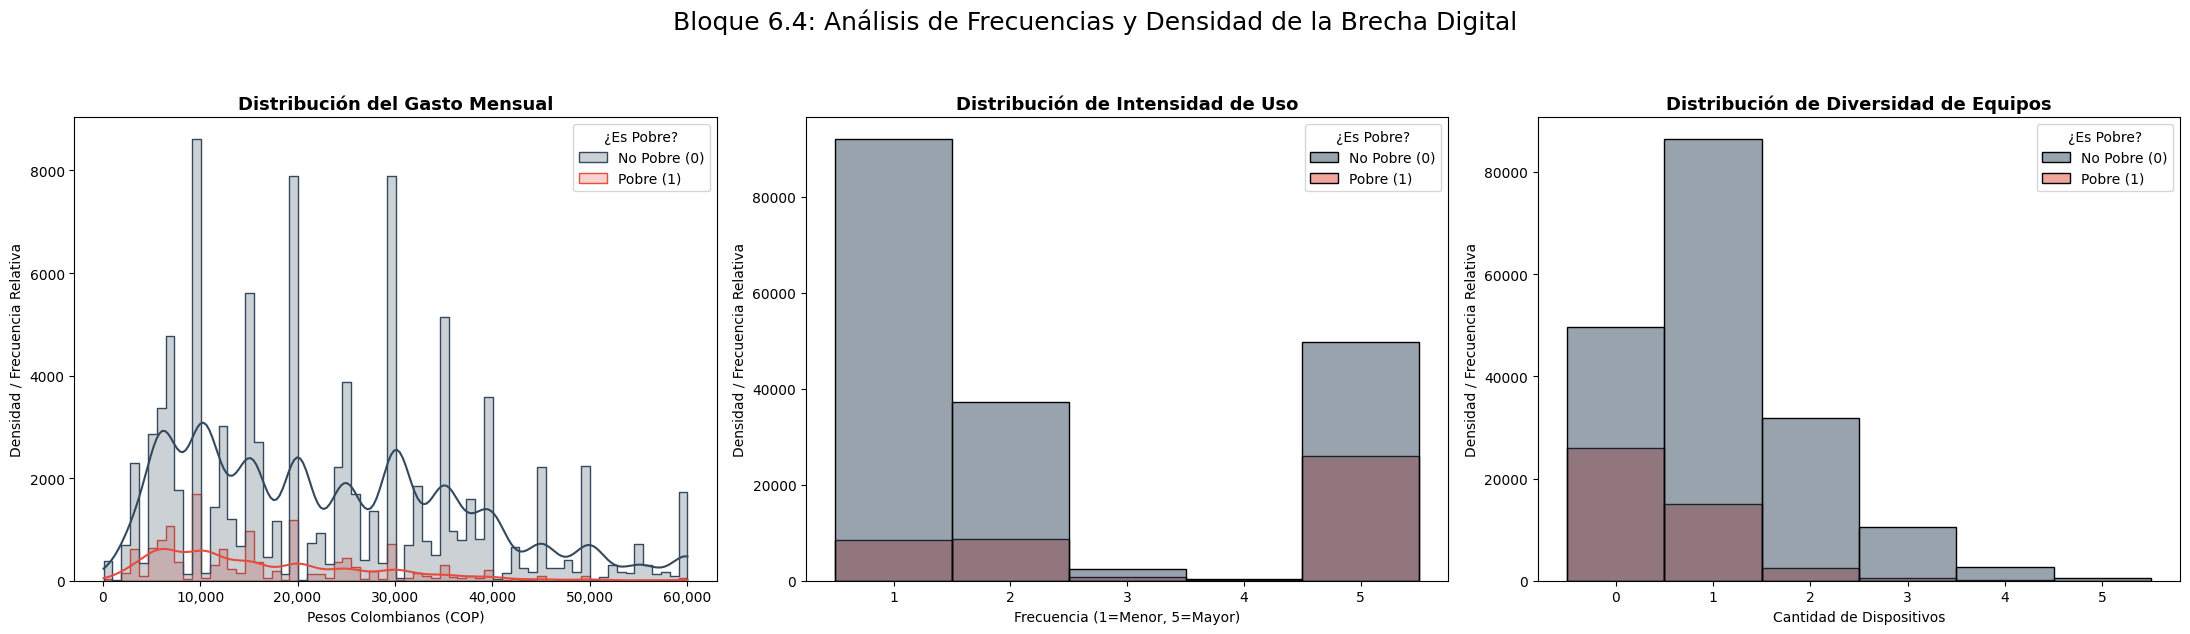

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de la figura
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))
paleta = ['#34495E', '#E74C3C']

# --- HISTOGRAMA 1: GASTO EN TELEFONÍA ---
# Usamos el df_gasto_plot que ya tiene el filtro de outliers del código anterior
sns.histplot(data=df_gasto_plot, x='Valor Pagado Servicio Telefonia', hue='POBRE', 
             element="step", kde=True, palette=paleta, ax=ax1, common_norm=False)
ax1.set_title('Distribución del Gasto Mensual', fontsize=13, fontweight='bold')
ax1.set_xlabel('Pesos Colombianos (COP)')
ax1.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# --- HISTOGRAMA 2: INTENSIDAD DE USO ---
sns.histplot(data=df_final, x='Frecuencia Uso Int', hue='POBRE', 
             element="bars", kde=False, palette=paleta, ax=ax2, discrete=True, common_norm=False)
ax2.set_title('Distribución de Intensidad de Uso', fontsize=13, fontweight='bold')
ax2.set_xlabel('Frecuencia (1=Menor, 5=Mayor)')

# --- HISTOGRAMA 3: DIVERSIDAD DE EQUIPOS ---
sns.histplot(data=df_final, x='Diversidad Dispositivos', hue='POBRE', 
             element="bars", kde=False, palette=paleta, ax=ax3, discrete=True, common_norm=False)
ax3.set_title('Distribución de Diversidad de Equipos', fontsize=13, fontweight='bold')
ax3.set_xlabel('Cantidad de Dispositivos')

# Ajustes finales
for ax in [ax1, ax2, ax3]:
    ax.set_ylabel('Densidad / Frecuencia Relativa')
    legend = ax.get_legend()
    if legend:
        legend.set_title('¿Es Pobre?')
        new_labels = ['No Pobre (0)', 'Pobre (1)']
        for t, l in zip(legend.get_texts(), new_labels): t.set_text(l)

plt.suptitle('Bloque 6.4: Análisis de Frecuencias y Densidad de la Brecha Digital', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

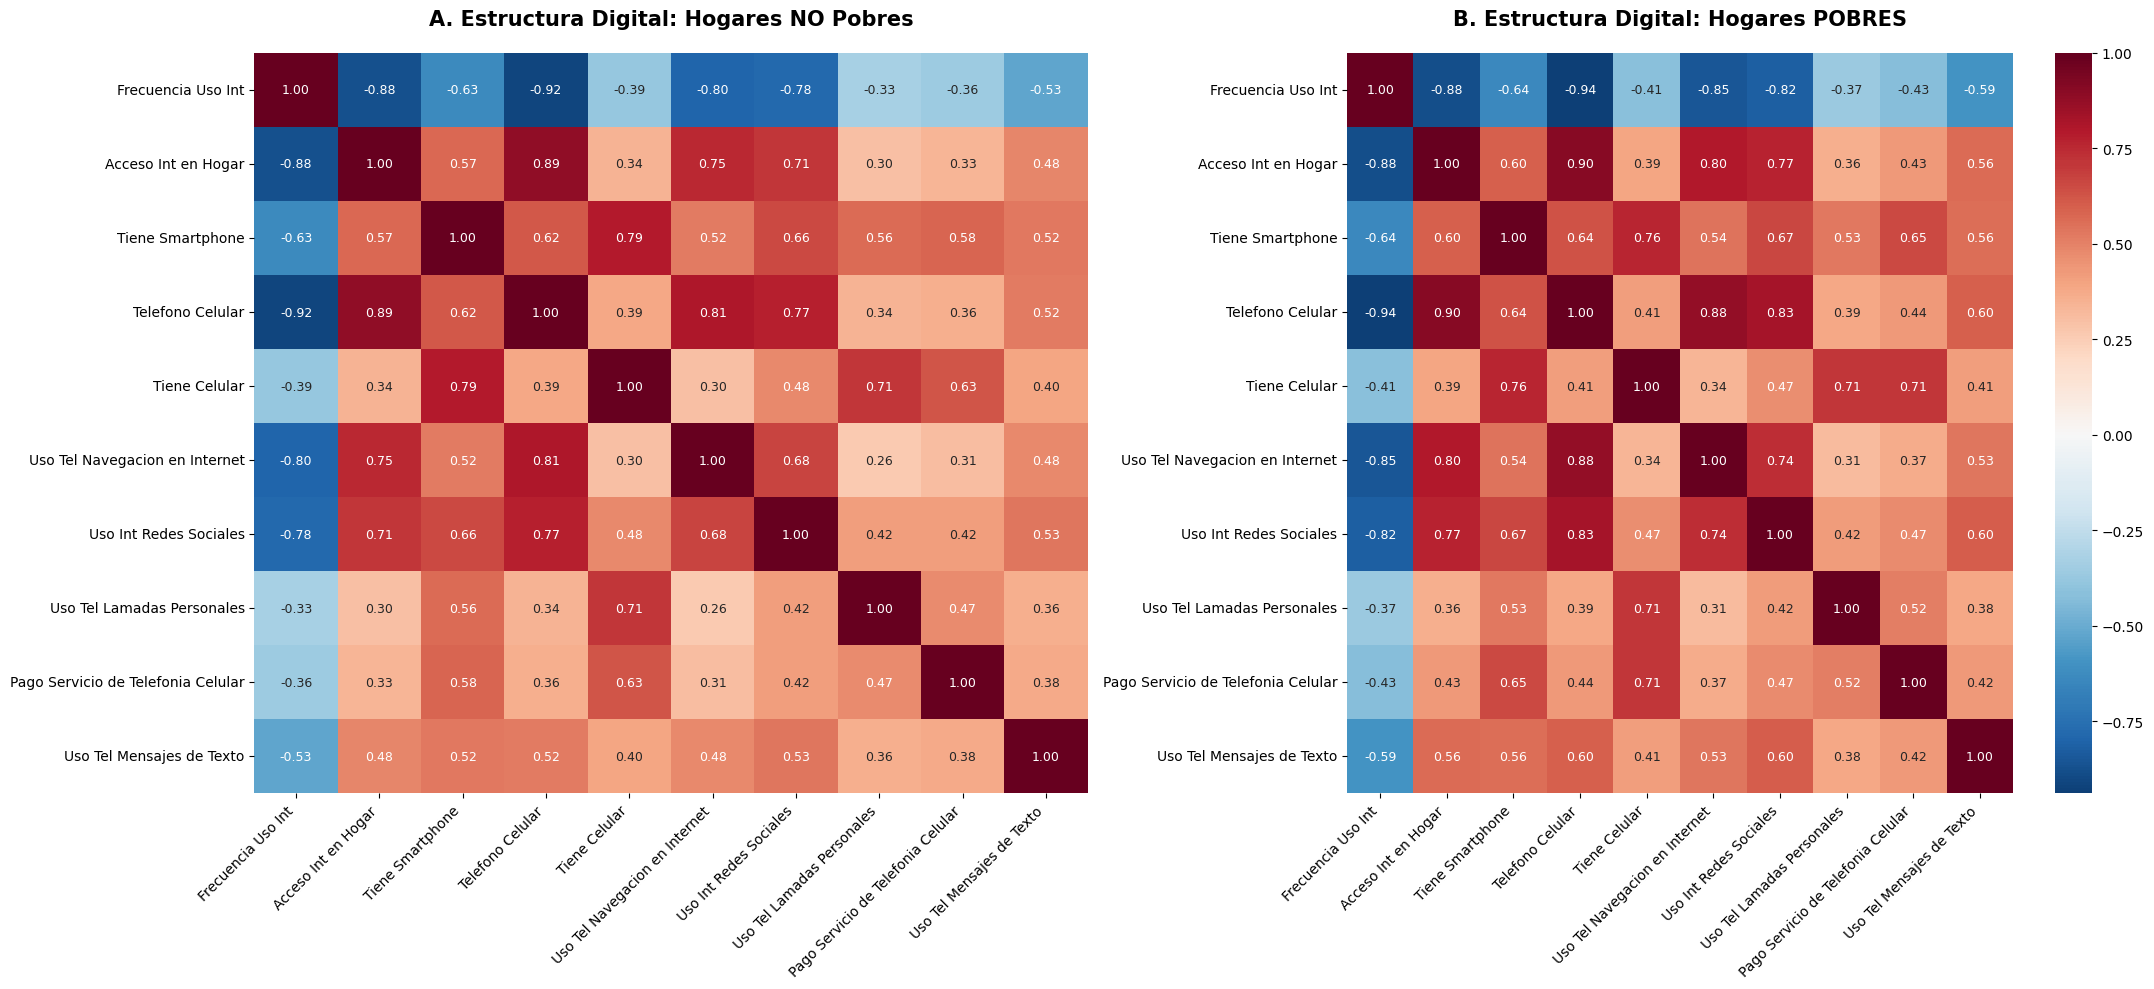

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos el Top 10 que ya conocemos (variables digitales más fuertes)
top_10_digital = [
    'Frecuencia Uso Int', 'Acceso Int en Hogar', 'Tiene Smartphone', 
    'Telefono Celular', 'Tiene Celular', 'Uso Tel Navegacion en Internet', 
    'Uso Int Redes Sociales', 'Uso Tel Lamadas Personales', 
    'Pago Servicio de Telefonia Celular', 'Uso Tel Mensajes de Texto'
]

# 2. Creamos dos subconjuntos de datos
df_pobres = df_listo[df_listo['POBRE'] == 1][top_10_digital].corr()
df_no_pobres = df_listo[df_listo['POBRE'] == 0][top_10_digital].corr()

# 3. Graficamos comparativamente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Mapa para No Pobres
sns.heatmap(df_no_pobres, annot=True, fmt=".2f", cmap='RdBu_r', center=0, 
            ax=ax1, cbar=False, annot_kws={"size": 9})
ax1.set_title('A. Estructura Digital: Hogares NO Pobres', fontsize=15, fontweight='bold', pad=20)

# Mapa para Pobres
sns.heatmap(df_pobres, annot=True, fmt=".2f", cmap='RdBu_r', center=0, 
            ax=ax2, annot_kws={"size": 9})
ax2.set_title('B. Estructura Digital: Hogares POBRES', fontsize=15, fontweight='bold', pad=20)

# Ajustes estéticos de etiquetas
for ax in [ax1, ax2]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [32]:
import session_info

# Esto genera un reporte de lo que REALMENTE se usó en esta sesión
session_info.show()